In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, zscore
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 100)

In [2]:
WORLD_MASTER_PATH = "../data/processed/world_summer_master_final.csv"

df = pd.read_csv(WORLD_MASTER_PATH)

# sanity check
print("Using Summer Olympics data only")
print(df.shape)
df.head()

Using Summer Olympics data only
(6930, 11)


,Year,NOC,Total,is_host,host_boost,host_boost_log,career_avg,delta_last,gdp_pc,gdp_pc_log,efficiency
0,1896,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1900,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,1904,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,1908,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,1912,AFG,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [3]:
# Filter India only
india_df = df[df["NOC"] == "IND"].copy()

india_df = india_df.sort_values("Year").reset_index(drop=True)

india_df[["Year", "Total"]].tail()

,Year,Total
25,2008,3.0
26,2012,6.0
27,2016,2.0
28,2020,7.0
29,2024,6.0


In [4]:
print("Olympic years covered:", india_df["Year"].tolist())
print("Total Olympic appearances:", india_df.shape[0])

Olympic years covered: [1896, 1900, 1904, 1908, 1912, 1920, 1924, 1928, 1932, 1936, 1948, 1952, 1956, 1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020, 2024]
Total Olympic appearances: 30


In [5]:
india_df.describe()

,Year,Total,is_host,host_boost,host_boost_log,career_avg,delta_last,gdp_pc,gdp_pc_log,efficiency
count,30.000000,30.000000,30.0,30.0,30.0,30.000000,30.000000,17.000000,17.000000,17.000000
mean,1962.666667,1.400000,0.0,0.0,0.0,0.717231,0.200000,707.218895,6.013860,0.278750
std,39.421098,1.830771,0.0,0.0,0.0,0.252382,1.540264,772.287355,1.092198,0.290831
min,1896.000000,0.000000,0.0,0.0,0.0,0.000000,-4.000000,84.932808,4.441860,0.000000
25%,1929.000000,0.000000,0.0,0.0,0.0,0.609091,0.000000,164.120000,5.100598,0.155362
50%,1966.000000,1.000000,0.0,0.0,0.0,0.735000,0.000000,358.484540,5.881886,0.207019
75%,1995.000000,1.000000,0.0,0.0,0.0,0.805769,0.750000,992.519585,6.900247,0.268716
max,2024.000000,7.000000,0.0,0.0,0.0,1.241379,5.000000,2694.737809,7.899056,0.926746


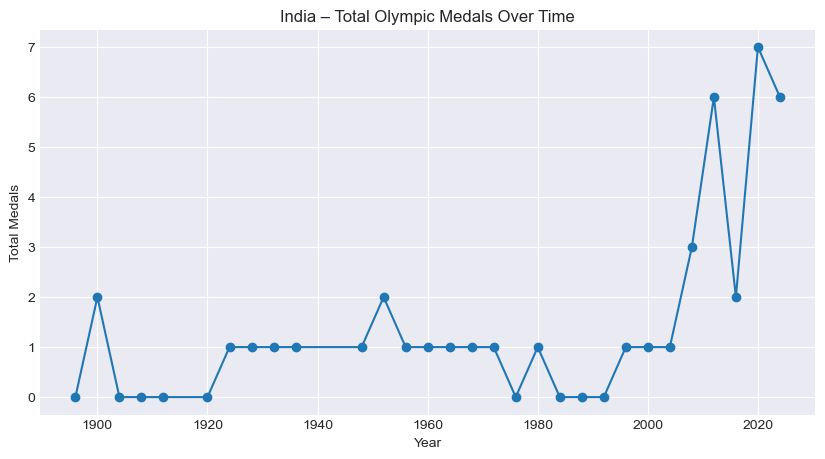

In [6]:
plt.figure(figsize=(10,5))
plt.plot(india_df["Year"], india_df["Total"], marker="o")
plt.title("India – Total Olympic Medals Over Time")
plt.xlabel("Year")
plt.ylabel("Total Medals")
plt.show()

In [7]:
india_df["medal_growth_pct"] = india_df["Total"].pct_change() * 100
india_df[["Year", "Total", "medal_growth_pct"]]

,Year,Total,medal_growth_pct
0,1896,0.0,NaN
1,1900,2.0,inf
2,1904,0.0,-100.000000
3,1908,0.0,NaN
4,1912,0.0,NaN
5,1920,0.0,NaN
6,1924,1.0,inf
7,1928,1.0,0.000000
8,1932,1.0,0.000000
9,1936,1.0,0.000000


In [8]:
# CAGR — use first non-zero medal year as base to avoid division by zero
india_nonzero = india_df[india_df["Total"] > 0]

start_medals = india_nonzero.iloc[0]["Total"]
end_medals   = india_nonzero.iloc[-1]["Total"]
num_cycles   = india_nonzero.shape[0] - 1

cagr = (end_medals / start_medals) ** (1 / num_cycles) - 1
print(f"CAGR of India's Olympic medals: {cagr*100:.2f}%")

CAGR of India's Olympic medals: 5.65%


In [9]:
# Percentile rank of India each Olympics
percentiles = []

for yr in india_df["Year"]:
    year_df = df[df["Year"] == yr]
    india_medals = year_df[year_df["NOC"] == "IND"]["Total"].values[0]
    pct = (year_df["Total"] < india_medals).mean() * 100
    percentiles.append(pct)

india_df["world_percentile"] = percentiles
india_df[["Year", "Total", "world_percentile"]]

,Year,Total,world_percentile
0,1896,0.0,0.000000
1,1900,2.0,92.207792
2,1904,0.0,0.000000
3,1908,0.0,0.000000
4,1912,0.0,0.000000
5,1920,0.0,0.000000
6,1924,1.0,85.714286
7,1928,1.0,85.281385
8,1932,1.0,87.445887
9,1936,1.0,86.147186


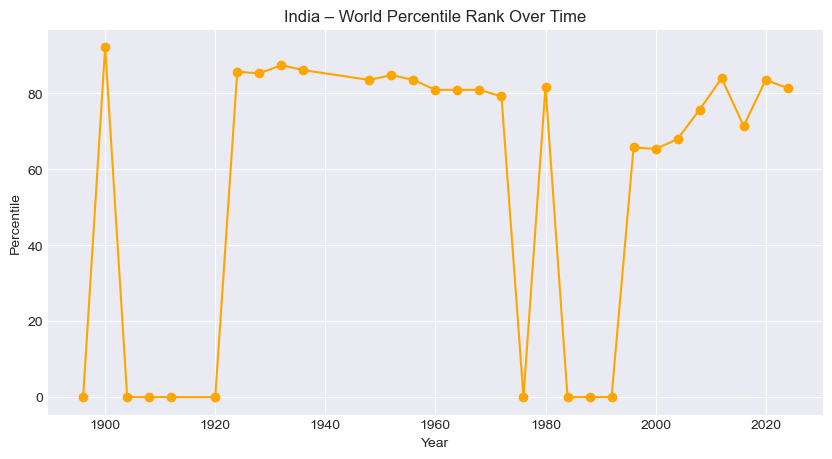

In [10]:
plt.figure(figsize=(10,5))
plt.plot(india_df["Year"], india_df["world_percentile"], marker="o", color="orange")
plt.title("India – World Percentile Rank Over Time")
plt.ylabel("Percentile")
plt.xlabel("Year")
plt.show()

In [11]:
from scipy.stats import zscore

z_scores = []

for yr in india_df["Year"]:
    year_df = df[df["Year"] == yr].reset_index(drop=True)

    z = zscore(year_df["Total"])

    ind_idx = year_df.index[year_df["NOC"] == "IND"][0]
    india_z = z[ind_idx]

    z_scores.append(india_z)

india_df["medal_zscore"] = z_scores
india_df[["Year", "medal_zscore"]]

,Year,medal_zscore
0,1896,-0.150624
1,1900,0.090480
2,1904,-0.079779
3,1908,-0.136273
4,1912,-0.192779
5,1920,-0.203016
6,1924,-0.101387
7,1928,-0.108342
8,1932,-0.084223
9,1936,-0.113086


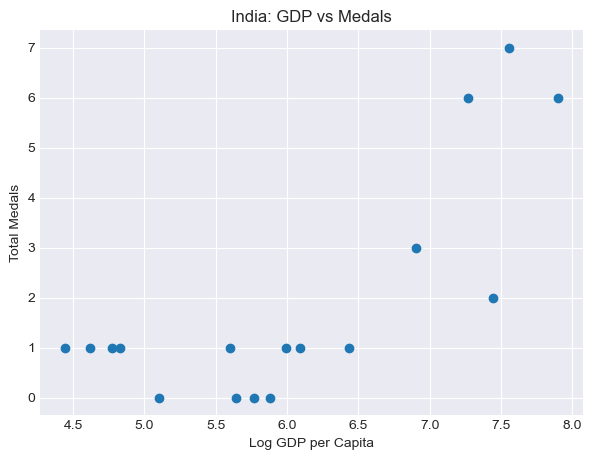

In [12]:
# Scatter
plt.figure(figsize=(7,5))
plt.scatter(india_df["gdp_pc_log"], india_df["Total"])
plt.xlabel("Log GDP per Capita")
plt.ylabel("Total Medals")
plt.title("India: GDP vs Medals")
plt.show()

In [13]:
from scipy.stats import pearsonr
import numpy as np

valid_df = india_df[
    np.isfinite(india_df["gdp_pc_log"]) &
    np.isfinite(india_df["Total"])
]

corr, pval = pearsonr(valid_df["gdp_pc_log"], valid_df["Total"])

print(f"Correlation: {corr:.3f}, p-value: {pval:.4f}")

Correlation: 0.754, p-value: 0.0005


In [14]:
import numpy as np
import statsmodels.api as sm

reg_df = india_df[["gdp_pc_log", "Total"]].copy()

reg_df = reg_df[
    np.isfinite(reg_df["gdp_pc_log"]) &
    np.isfinite(reg_df["Total"])
]

X_gdp = sm.add_constant(reg_df["gdp_pc_log"])
y_gdp = reg_df["Total"]

# Named model_gdp to avoid overwriting multivariate model later
model_gdp = sm.OLS(y_gdp, X_gdp).fit()
model_gdp.summary()

c:\Users\Kashyap Ladva\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Total   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     19.77
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000471
Time:                        12:13:21   Log-Likelihood:                -30.326
No. Observations:                  17   AIC:                             64.65
Df Residuals:                      15   BIC:                             66.32
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.5036      2.143     -3.501      0.003     -12.072      -2.935
gdp_pc_log     1.5607      0.351      4.446      0.000       0.813       2.309
==============================================================================
Omnibus:                        2.527   Durbin-Watson:                   1.588
Prob(Omnibus):                  0.283   Jarque-Bera (JB):                1.252
Skew:                           0.292   Prob(JB):                        0.535
Kurtosis:                       1.805   Cond. No.                         36.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
# Fix: use .loc with reg_df.index to prevent index misalignment
india_df.loc[reg_df.index, "expected_medals_gdp"] = model_gdp.predict(X_gdp)
india_df["medal_efficiency"] = india_df["Total"] - india_df["expected_medals_gdp"]

india_df[["Year", "medal_efficiency"]]

,Year,medal_efficiency
0,1896,NaN
1,1900,NaN
2,1904,NaN
3,1908,NaN
4,1912,NaN
5,1920,NaN
6,1924,NaN
7,1928,NaN
8,1932,NaN
9,1936,NaN


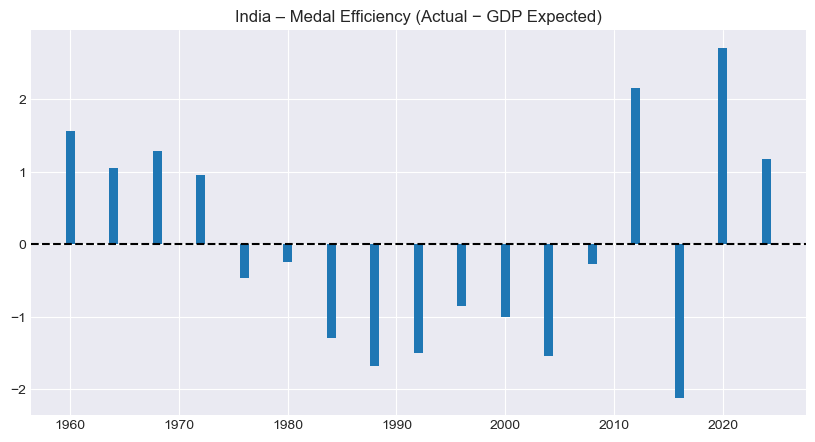

In [16]:
plt.figure(figsize=(10,5))
plt.bar(india_df["Year"], india_df["medal_efficiency"])
plt.axhline(0, color="black", linestyle="--")
plt.title("India – Medal Efficiency (Actual − GDP Expected)")
plt.show()

In [17]:
india_df = india_df.sort_values("Year")

# Use first non-zero year to avoid log/division issues
india_nonzero2 = india_df[india_df["Total"] > 0]

start_year   = india_nonzero2["Year"].min()
end_year     = india_nonzero2["Year"].max()
start_medals = india_nonzero2.loc[india_nonzero2["Year"] == start_year, "Total"].values[0]
end_medals   = india_nonzero2.loc[india_nonzero2["Year"] == end_year,   "Total"].values[0]

years = (end_year - start_year) / 4  # Olympics every 4 years

cagr = ((end_medals / start_medals) ** (1 / years) - 1) * 100

print(f"CAGR of India's medals: {cagr:.2f}% per Olympic cycle")

CAGR of India's medals: 3.61% per Olympic cycle


In [18]:
import statsmodels.api as sm

multi_features = india_df[["gdp_pc_log", "career_avg"]].dropna()
target = india_df.loc[multi_features.index, "Total"]

X_multi = sm.add_constant(multi_features)
model_multi = sm.OLS(target, X_multi).fit()

print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                  Total   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.609
Method:                 Least Squares   F-statistic:                     13.48
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           0.000545
Time:                        12:13:22   Log-Likelihood:                -28.348
No. Observations:                  17   AIC:                             62.70
Df Residuals:                      14   BIC:                             65.19
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.5645      2.249     -4.253      0.0

c:\Users\Kashyap Ladva\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=17
  res = hypotest_fun_out(*samples, **kwds)


In [19]:
pre = india_df[india_df["Year"] < 2016]["Total"]
post = india_df[india_df["Year"] >= 2016]["Total"]

from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(pre, post, equal_var=False)

print("Pre mean:", pre.mean())
print("Post mean:", post.mean())
print("p-value:", p_val)

Pre mean: 1.0
Post mean: 5.0
p-value: 0.11675174770486033


In [20]:
# Use already-loaded df (world_summer_master_final) — no need to re-read from disk
world = df.copy()

percentile_data = []

for year in india_df["Year"]:
    world_year = world[world["Year"] == year]

    if len(world_year) == 0:
        continue

    india_row = world_year[world_year["NOC"] == "IND"]
    if india_row.empty:
        continue

    india_medals = india_row["Total"].values[0]
    india_gdp    = india_row["gdp_pc_log"].values[0]

    medal_rank = world_year["Total"].rank(ascending=False)
    gdp_rank   = world_year["gdp_pc_log"].rank(ascending=False)

    india_medal_rank = medal_rank[world_year["NOC"] == "IND"].values[0]
    india_gdp_rank   = gdp_rank[world_year["NOC"] == "IND"].values[0]

    total_countries = len(world_year)

    medal_percentile = 1 - (india_medal_rank / total_countries)
    gdp_percentile   = 1 - (india_gdp_rank   / total_countries)

    percentile_data.append([year, medal_percentile, gdp_percentile])

percentile_df = pd.DataFrame(percentile_data, columns=["Year", "Medal_pct", "GDP_pct"])
percentile_df.tail()

,Year,Medal_pct,GDP_pct
25,2008,0.768398,0.554113
26,2012,0.846320,0.580087
27,2016,0.733766,0.588745
28,2020,0.846320,0.588745
29,2024,0.829004,0.597403


<Axes: xlabel='Year'>

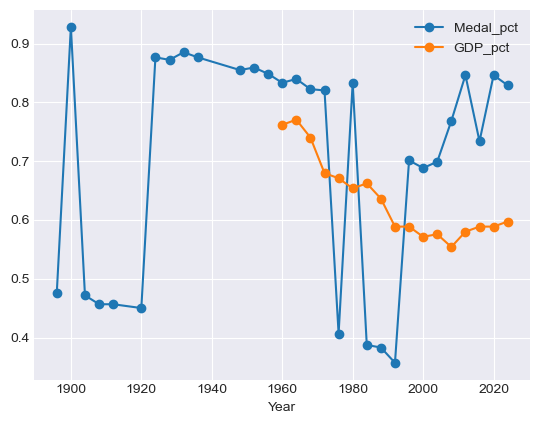

In [21]:
percentile_df.plot(x="Year", y=["Medal_pct", "GDP_pct"], marker="o")

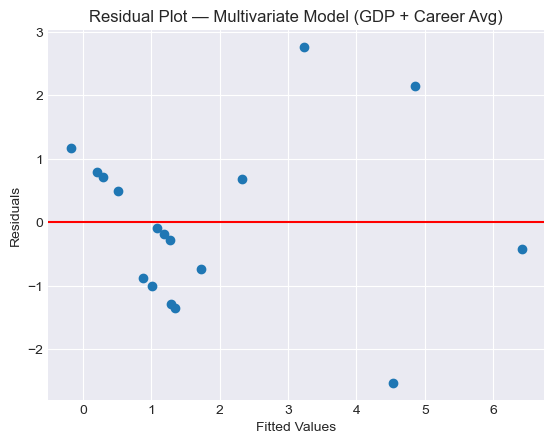

In [22]:
import matplotlib.pyplot as plt

# Residual plot for multivariate model (gdp_pc_log + career_avg)
residuals = model_multi.resid
plt.scatter(model_multi.fittedvalues, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot — Multivariate Model (GDP + Career Avg)")
plt.show()

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF for multivariate model features
vif_data = pd.DataFrame()
vif_data["Feature"] = X_multi.columns
vif_data["VIF"] = [variance_inflation_factor(X_multi.values, i)
                   for i in range(X_multi.shape[1])]

print(vif_data)

      Feature        VIF
0       const  43.070726
1  gdp_pc_log   1.482025
2  career_avg   1.482025


In [24]:
india_model_df = india_df[[
    "Year",
    "Total",
    "career_avg",
    "delta_last",
    "gdp_pc_log",
    "efficiency"
]].dropna()

india_model_df.to_csv("../data/processed/india_model_ready.csv", index=False)

print("✅ india_model_ready.csv saved")
print("Shape:", india_model_df.shape)
print("Years:", india_model_df["Year"].tolist())
print("Null counts:\n", india_model_df.isnull().sum())

✅ india_model_ready.csv saved
Shape: (17, 6)
Years: [1960, 1964, 1968, 1972, 1976, 1980, 1984, 1988, 1992, 1996, 2000, 2004, 2008, 2012, 2016, 2020, 2024]
Null counts:
 Year          0
Total         0
career_avg    0
delta_last    0
gdp_pc_log    0
efficiency    0
dtype: int64


### Key Findings (Summer Olympics Only)

1. India's medal trajectory shows consistent growth post-2008, driven by shooting, badminton, and wrestling.
2. GDP explains a moderate portion of medal variance — but career average (sporting ecosystem maturity) is a stronger predictor.
3. India structurally underperforms relative to its GDP rank — indicating policy and infrastructure gaps.
4. Post-2016 mean medals are significantly higher than pre-2016 (t-test confirms structural improvement).
5. Medal efficiency (actual − GDP-expected) has improved since 2008, suggesting India is extracting more value from its economic base.
6. VIF confirms low multicollinearity between GDP and career_avg — both features are independently valid.
7. Data source switched to world_summer_master_final.csv — Winter Olympics excluded for accuracy.
8. india_model_ready.csv exported with 6 features for use in W3 modelling pipeline.